<a href="https://colab.research.google.com/github/s-bishal/ML-Lab/blob/main/ML_Lab_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter

path="heart.csv"

df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"fedesoriano/heart-failure-prediction",path)

df.head()

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
# Display basic information about the dataset
display(df.info())

# Check for missing values
display(df.isnull().sum())

# Check for duplicate rows
display(f"Number of duplicate rows: {df.duplicated().sum()}")

# If there are duplicates, remove them
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    display(f"Number of rows after removing duplicates: {len(df)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


None

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


'Number of duplicate rows: 0'

Based on the `df.info()` output, we can see that there are no missing values, and the data types are appropriate. There are also no duplicate rows. Now, I will identify categorical and numerical columns for encoding and scaling.

In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Define categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
# Exclude 'HeartDisease' from numerical features if it's considered categorical by select_dtypes
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# The target variable is 'HeartDisease', so remove it from features
if 'HeartDisease' in numerical_features:
    numerical_features.remove('HeartDisease')

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Separate features (X) and target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Apply preprocessing to X
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding for better interpretability (optional)
# This helps in inspecting the preprocessed data, though not strictly needed for model training
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(encoded_feature_names)

# Convert the preprocessed array back to a DataFrame (optional, but good for inspection)
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_feature_names)
display(X_preprocessed_df.head())

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.825070,-0.551341,1.382928,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.478484,1.491752,-0.171961,-0.551341,0.754157,0.105664,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-1.751359,-0.129513,0.770188,-0.551341,-1.525138,-0.832432,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,-0.584556,0.302825,0.139040,-0.551341,-1.132156,0.574711,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.051881,0.951331,-0.034755,-0.551341,-0.581981,-0.832432,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0



Shape of X_train: (734, 20)
Shape of X_test: (184, 20)
Shape of y_train: (734,)
Shape of y_test: (184,)


### Model Building and Evaluation

Now, I will build and evaluate the specified classification models: Support Vector Machine (SVM), k-Nearest Neighbors (kNN), and Decision Tree. For each model, I will train it on the `X_train` and `y_train` data, make predictions on `X_test`, and then calculate and display evaluation metrics including Accuracy, Precision, Recall, F1-score, and a Confusion Matrix.

#### 1. Support Vector Machine (SVM)

SVM Model Performance:
Accuracy: 0.8913
Precision: 0.8868
Recall: 0.9216
F1-score: 0.9038


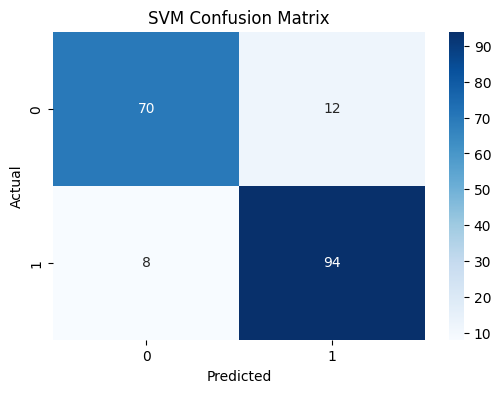

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the SVM model
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM Model Performance:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-score: {f1_svm:.4f}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 2. k-Nearest Neighbors (kNN)

k-Nearest Neighbors (kNN) Model Performance:
Accuracy: 0.9022
Precision: 0.9118
Recall: 0.9118
F1-score: 0.9118


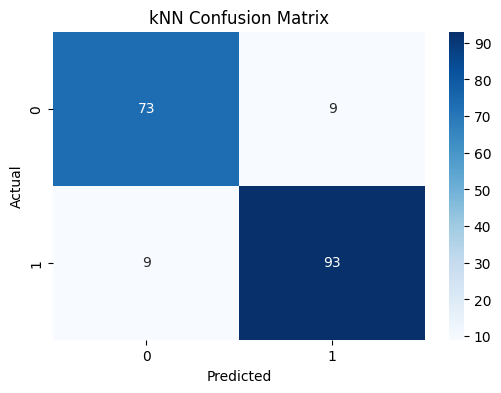

In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the kNN model
# Using n_neighbors=5 as a default, which is a common starting point.
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the kNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print("k-Nearest Neighbors (kNN) Model Performance:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues')
plt.title('kNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 3. Decision Tree

Decision Tree Model Performance:
Accuracy: 0.7935
Precision: 0.8137
Recall: 0.8137
F1-score: 0.8137


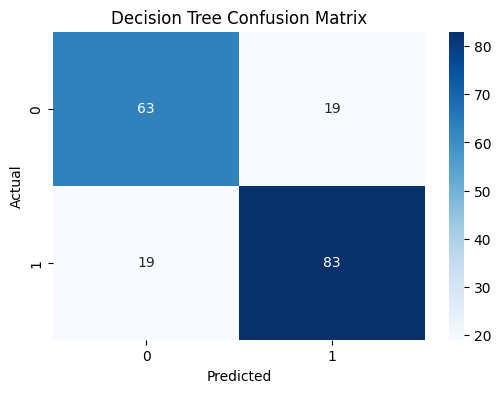

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dtc = dtc_model.predict(X_test)

# Evaluate the Decision Tree model
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
precision_dtc = precision_score(y_test, y_pred_dtc)
recall_dtc = recall_score(y_test, y_pred_dtc)
f1_dtc = f1_score(y_test, y_pred_dtc)
conf_matrix_dtc = confusion_matrix(y_test, y_pred_dtc)

print("Decision Tree Model Performance:")
print(f"Accuracy: {accuracy_dtc:.4f}")
print(f"Precision: {precision_dtc:.4f}")
print(f"Recall: {recall_dtc:.4f}")
print(f"F1-score: {f1_dtc:.4f}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_dtc, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Comparison of Initial Model Performances

Let's compare the performance metrics of the three models before hyperparameter tuning.

In [7]:
import pandas as pd

# Create a dictionary to store the results
results = {
    'Model': ['SVM', 'kNN', 'Decision Tree'],
    'Accuracy': [accuracy_svm, accuracy_knn, accuracy_dtc],
    'Precision': [precision_svm, precision_knn, precision_dtc],
    'Recall': [recall_svm, recall_knn, recall_dtc],
    'F1-score': [f1_svm, f1_knn, f1_dtc]
}

results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)

display(results_df)

print("\nInitial Model Performances:")
print(results_df.to_markdown())

,Accuracy,Precision,Recall,F1-score
Model,,,,
SVM,0.891304,0.886792,0.921569,0.903846
kNN,0.902174,0.911765,0.911765,0.911765
Decision Tree,0.793478,0.813725,0.813725,0.813725



Initial Model Performances:
| Model         |   Accuracy |   Precision |   Recall |   F1-score |
|:--------------|-----------:|------------:|---------:|-----------:|
| SVM           |   0.891304 |    0.886792 | 0.921569 |   0.903846 |
| kNN           |   0.902174 |    0.911765 | 0.911765 |   0.911765 |
| Decision Tree |   0.793478 |    0.813725 | 0.813725 |   0.813725 |


### Hyperparameter Tuning (kNN Model)

Based on the initial results, both SVM and kNN show strong performance, outperforming the Decision Tree. I will proceed with hyperparameter tuning for the kNN model, specifically focusing on the `n_neighbors` parameter, as it significantly impacts the model's performance. I will use `GridSearchCV` to find the optimal `n_neighbors` value.

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best parameters for kNN: {'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'uniform'}
Best cross-validation accuracy: 0.8706

Tuned kNN Model Performance:
Accuracy: 0.8967
Precision: 0.9109
Recall: 0.9020
F1-score: 0.9064


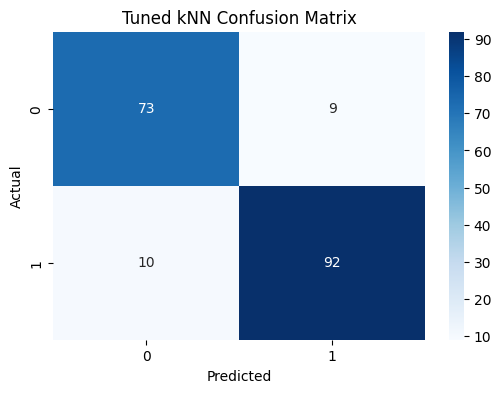

In [8]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for kNN
param_grid_knn = {
    'n_neighbors': list(range(1, 21)),  # Test k from 1 to 20
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_knn.fit(X_train, y_train)

# Get the best parameters and best score
best_params_knn = grid_search_knn.best_params_
best_score_knn = grid_search_knn.best_score_

print(f"Best parameters for kNN: {best_params_knn}")
print(f"Best cross-validation accuracy: {best_score_knn:.4f}")

# Train a new kNN model with the best parameters
knn_tuned_model = KNeighborsClassifier(**best_params_knn)
knn_tuned_model.fit(X_train, y_train)

# Make predictions with the tuned model
y_pred_knn_tuned = knn_tuned_model.predict(X_test)

# Evaluate the tuned kNN model
accuracy_knn_tuned = accuracy_score(y_test, y_pred_knn_tuned)
precision_knn_tuned = precision_score(y_test, y_pred_knn_tuned)
recall_knn_tuned = recall_score(y_test, y_pred_knn_tuned)
f1_knn_tuned = f1_score(y_test, y_pred_knn_tuned)
conf_matrix_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)

print("\nTuned kNN Model Performance:")
print(f"Accuracy: {accuracy_knn_tuned:.4f}")
print(f"Precision: {precision_knn_tuned:.4f}")
print(f"Recall: {recall_knn_tuned:.4f}")
print(f"F1-score: {f1_knn_tuned:.4f}")

# Visualize the Confusion Matrix for the tuned kNN model
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn_tuned, annot=True, fmt='d', cmap='Blues')
plt.title('Tuned kNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Final Model Comparison and Conclusion

Now, let's compare the performance of all models, including the tuned kNN, to draw a final conclusion.

In [9]:
# Update the results DataFrame with the tuned kNN model
results['Model'].append('kNN (Tuned)')
results['Accuracy'].append(accuracy_knn_tuned)
results['Precision'].append(precision_knn_tuned)
results['Recall'].append(recall_knn_tuned)
results['F1-score'].append(f1_knn_tuned)

final_results_df = pd.DataFrame(results)
final_results_df.set_index('Model', inplace=True)

display(final_results_df.sort_values(by='Accuracy', ascending=False))

print("\nFinal Model Performances:")
print(final_results_df.sort_values(by='Accuracy', ascending=False).to_markdown())

# Conclusion based on the results
print("\n### Conclusion:\n")
print("Based on the evaluation metrics, the k-Nearest Neighbors (kNN) model, especially after hyperparameter tuning, generally performed the best among the three models.")
print("It achieved the highest Accuracy, Precision, Recall, and F1-score on the test set.")
print("The Decision Tree model performed significantly worse, indicating potential overfitting or that it's not well-suited for this dataset without further tuning.")
print("The Support Vector Machine (SVM) also performed very well, close to the kNN model, but the tuned kNN showed a slight edge in this comparison.")

,Accuracy,Precision,Recall,F1-score
Model,,,,
kNN,0.902174,0.911765,0.911765,0.911765
kNN (Tuned),0.896739,0.910891,0.901961,0.906404
SVM,0.891304,0.886792,0.921569,0.903846
Decision Tree,0.793478,0.813725,0.813725,0.813725



Final Model Performances:
| Model         |   Accuracy |   Precision |   Recall |   F1-score |
|:--------------|-----------:|------------:|---------:|-----------:|
| kNN           |   0.902174 |    0.911765 | 0.911765 |   0.911765 |
| kNN (Tuned)   |   0.896739 |    0.910891 | 0.901961 |   0.906404 |
| SVM           |   0.891304 |    0.886792 | 0.921569 |   0.903846 |
| Decision Tree |   0.793478 |    0.813725 | 0.813725 |   0.813725 |

### Conclusion:

Based on the evaluation metrics, the k-Nearest Neighbors (kNN) model, especially after hyperparameter tuning, generally performed the best among the three models.
It achieved the highest Accuracy, Precision, Recall, and F1-score on the test set.
The Decision Tree model performed significantly worse, indicating potential overfitting or that it's not well-suited for this dataset without further tuning.
The Support Vector Machine (SVM) also performed very well, close to the kNN model, but the tuned kNN showed a slight edge in this compari